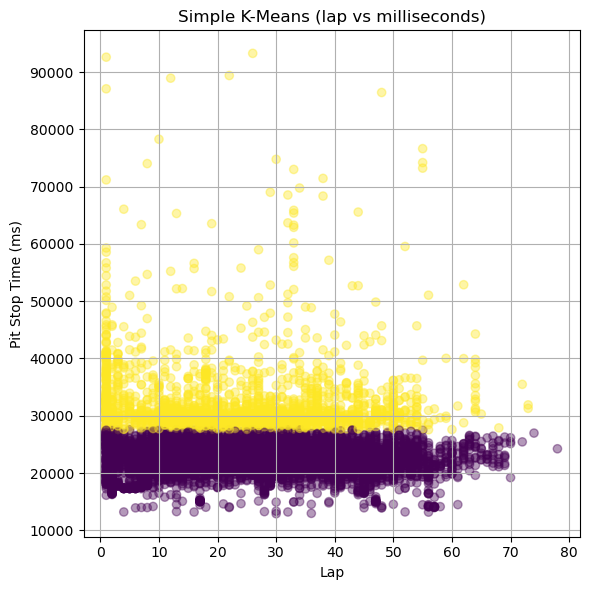


===== SIMPLE LINEAR REGRESSION =====
MAE: 2281.8703230142287
RMSE: 4693.785122973484
R²: 0.2953403950052459


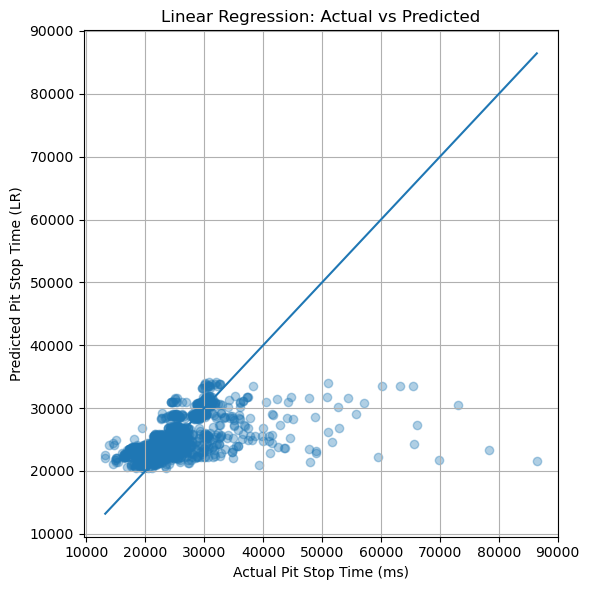


===== SIMPLE RANDOM FOREST =====
MAE: 2365.0081834396847
RMSE: 4723.134767230871
R²: 0.28650054928850677

Feature Importance:
avg_ms       0.462849
lap          0.319862
stop         0.105610
circuitId    0.064843
alt          0.046837
dtype: float64


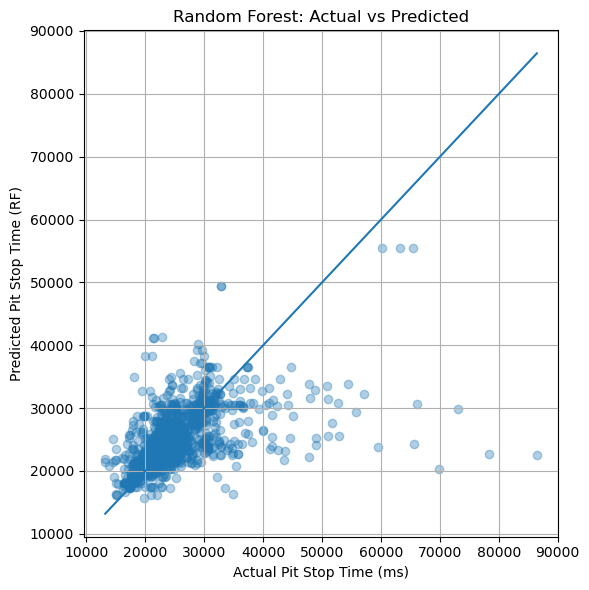

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =========================
# 1. LOAD + MINIMAL MERGE
# =========================
pit = pd.read_csv("pit_stops.csv")
races = pd.read_csv("races.csv")
circuits = pd.read_csv("circuits.csv")

# Filter modern races
pit = pit[pit["raceId"] >= 841].copy()
races = races[races["raceId"] >= 841].copy()

# Merge pit -> race (to add circuitId)
df = pit.merge(races[["raceId", "circuitId"]], on="raceId", how="left")

# Merge circuit altitude
df = df.merge(circuits[["circuitId", "alt"]], on="circuitId", how="left")

# Clean pit stop times
df = df[df["milliseconds"].between(1000, 100000)].copy()
df["alt"] = df["alt"].fillna(df["alt"].median())

# =========================
# 2. ONE SIMPLE FEATURE: avg_ms per circuit
# =========================
avg_ms_per_circuit = (
    df.groupby("circuitId")["milliseconds"].mean().rename("avg_ms")
)
df = df.merge(avg_ms_per_circuit, on="circuitId", how="left")

# =========================
# 3. SIMPLE K-MEANS
# =========================
X_km = df[["lap", "milliseconds"]]

kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X_km)

plt.figure(figsize=(6,6))
plt.scatter(df["lap"], df["milliseconds"], c=df["cluster"], alpha=0.4)
plt.xlabel("Lap")
plt.ylabel("Pit Stop Time (ms)")
plt.title("Simple K-Means (lap vs milliseconds)")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 4. SIMPLE LINEAR REGRESSION
# =========================
X_lin = df[["lap", "stop", "avg_ms", "alt"]]
y = df["milliseconds"]

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_lin_scaled = scaler.fit_transform(X_train_lin)
X_test_lin_scaled = scaler.transform(X_test_lin)

linreg = LinearRegression()
linreg.fit(X_train_lin_scaled, y_train_lin)
y_pred_lr = linreg.predict(X_test_lin_scaled)

print("\n===== SIMPLE LINEAR REGRESSION =====")
print("MAE:", mean_absolute_error(y_test_lin, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_lin, y_pred_lr)))
print("R²:", linreg.score(X_test_lin_scaled, y_test_lin))

# ---------- GRAPH: LR Actual vs Predicted ----------
plt.figure(figsize=(6,6))
plt.scatter(y_test_lin, y_pred_lr, alpha=0.35)
min_val = min(y_test_lin.min(), y_pred_lr.min())
max_val = max(y_test_lin.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val])  # perfect prediction line
plt.xlabel("Actual Pit Stop Time (ms)")
plt.ylabel("Predicted Pit Stop Time (LR)")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 5. SIMPLE RANDOM FOREST
# =========================
X_rf = df[["lap", "stop", "circuitId", "avg_ms", "alt"]]
y_rf = df["milliseconds"]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

print("\n===== SIMPLE RANDOM FOREST =====")
print("MAE:", mean_absolute_error(y_test_rf, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_rf, y_pred_rf)))
print("R²:", rf.score(X_test_rf, y_test_rf))

print("\nFeature Importance:")
print(pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False))

# ---------- GRAPH: RF Actual vs Predicted ----------
plt.figure(figsize=(6,6))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.35)
min_val = min(y_test_rf.min(), y_pred_rf.min())
max_val = max(y_test_rf.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val])  # perfect prediction line
plt.xlabel("Actual Pit Stop Time (ms)")
plt.ylabel("Predicted Pit Stop Time (RF)")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


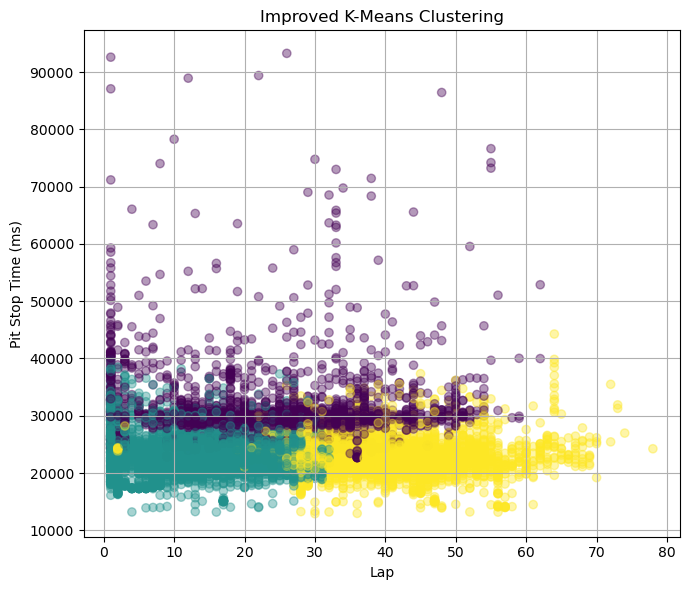


===== CLUSTER CENTERS (original units) =====
   milliseconds        lap      stop        avg_ms         alt
0  31696.712267  23.646643  1.681474  29435.577203   81.350328
1  23086.210715  15.339972  1.241785  23541.461650  214.254133
2  22885.945904  39.980165  2.512365  23450.988051  271.258887


In [17]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Use your df from earlier merges ---
# (df already contains lap, stop, avg_ms, alt, std_ms, avg_pits_per_race)

# Select improved clustering features
X = df[[
    "milliseconds",
    "lap",
    "stop",
    "avg_ms",
    "alt",
]].fillna(0)

# Scale features so no single column dominates
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try 3 clusters (often best for pit stops)
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Plot milliseconds vs lap colored by cluster
plt.figure(figsize=(7,6))
plt.scatter(df["lap"], df["milliseconds"], c=df["cluster"], cmap="viridis", alpha=0.4)
plt.xlabel("Lap")
plt.ylabel("Pit Stop Time (ms)")
plt.title("Improved K-Means Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()

# Convert cluster centers back to original units
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

cluster_centers = pd.DataFrame(
    centers,
    columns=[
        "milliseconds",
        "lap",
        "stop",
        "avg_ms",
        "alt",
    ]
)

print("\n===== CLUSTER CENTERS (original units) =====")
print(cluster_centers)

